In [48]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler


#tl.tenalg.set_backend('einsum')
#tl.plugins.use_opt_einsum()
    
mne.set_log_level('ERROR')
print(tl.get_backend())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 23.2.1 -> 24.1
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
cupy


In [49]:
%env CUPY_CUDA_PER_THREAD_DEFAULT_STREAM

'1'

In [50]:
%env TENSORLY_BACKEND

'cupy'

In [51]:
from moabb.paradigms import P300, LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=48)
dataset = Huebner2017()
#sfreq=500
#paradigm=LeftRightImagery(resample=sfreq)
#dataset = BNCI2014_004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[8],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


In [52]:
meta

,subject,session,run
0,8,0,0
1,8,0,0
2,8,0,0
3,8,0,0
4,8,0,0
...,...,...,...
4278,8,0,8
4279,8,0,8
4280,8,0,8
4281,8,0,8


In [53]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from sklearn.model_selection import train_test_split
from hoda.tensorize import stf_tensor

X = epochs.get_data()
#X = stf_tensor(X, sfreq=sfreq, zscore=False, morlet_params=dict(n_jobs=-1))
X = tl.tensor(X)
y = labels


print(X.shape)
print(X.dtype)

(4283, 31, 43)
float32


In [54]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler


bttda = GreedyBTTDA(
    max_blocks=4,
    truncate=False,
    #rank_grid=[1,2,3],
    rank_grid=None,
    hoda_params=dict(
        rank=None,
        max_iter=256,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=-1,    
)
%lprun -f bttda.fit bttda.fit(X,y)

Model selection block 1/4...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 4/4...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 551.28 s
File: /project/src/hoda/hoda.py
Function: fit at line 807

Line #      Hits         Time  Per Hit   % Time  Line Contents
   807                                               def fit(self, X, y, X_test=None, y_test=None):
   808         1       8129.0   8129.0      0.0          assert tl.is_tensor(X)
   809         1       2478.0   2478.0      0.0          n_samples, *shape = X.shape
   810                                           
   811         1        337.0    337.0      0.0          cv = self.cv
   812         1        269.0    269.0      0.0          if cv is None:
   813                                                       cv = StratifiedKFold(shuffle=True)
   814         1        160.0    160.0      0.0          rank_grid = self.rank_grid
   815         1        206.0    206.0      0.0          if rank_grid is None:
   816         2       5324.0   2662.0      0.0              rank_grid = list(
   817         1      48899.0  48899.0   

In [55]:
bttda.model_select_info_

,fold,rank,hoda,train_score,val_score,block,best
0,0,1,"HODA(random_state=42, rank=1, verbose=True)",0.917388,0.908548,0,False
1,0,2,"HODA(random_state=42, rank=2, verbose=True)",0.959297,0.955589,0,False
2,0,4,"HODA(random_state=42, rank=4, verbose=True)",0.970897,0.968899,0,False
3,0,8,"HODA(random_state=42, rank=8, verbose=True)",0.979022,0.969519,0,True
4,0,16,"HODA(random_state=42, rank=16, verbose=True)",0.984576,0.968143,0,False
...,...,...,...,...,...,...,...
25,4,2,"HODA(random_state=42, rank=2, verbose=True)",0.982035,0.961202,3,False
26,4,4,"HODA(random_state=42, rank=4, verbose=True)",0.983571,0.958984,3,False
27,4,8,"HODA(random_state=42, rank=8, verbose=True)",0.984145,0.958042,3,False
28,4,16,"HODA(random_state=42, rank=16, verbose=True)",0.984832,0.955771,3,False


<Axes: xlabel='block', ylabel='val_score'>

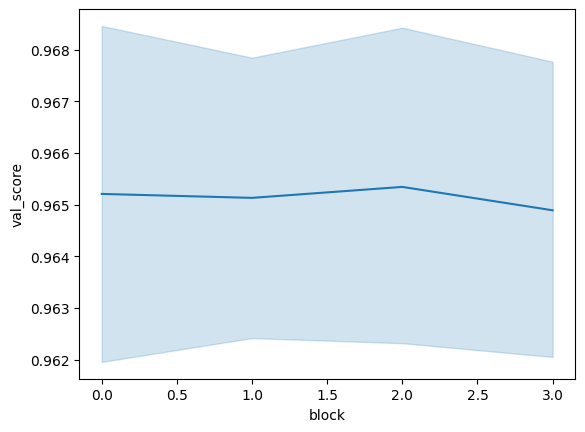

In [56]:
import seaborn as sns 
df_best = bttda.model_select_info_[bttda.model_select_info_['best']]
sns.lineplot(data=df_best, x='block',y='val_score')

In [42]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,mse,nmse,F_tr,F_rt
0,1,"(4, 4)",4.230679e-11,0.897242,0.133558,0.001607
1,2,"(8, 8)",3.113701e-11,0.660354,0.018552,0.001786
2,3,"(2, 2)",3.070046e-11,0.651095,0.018554,0.001795
3,4,"(4, 4)",2.848397e-11,0.604088,0.018463,0.001838


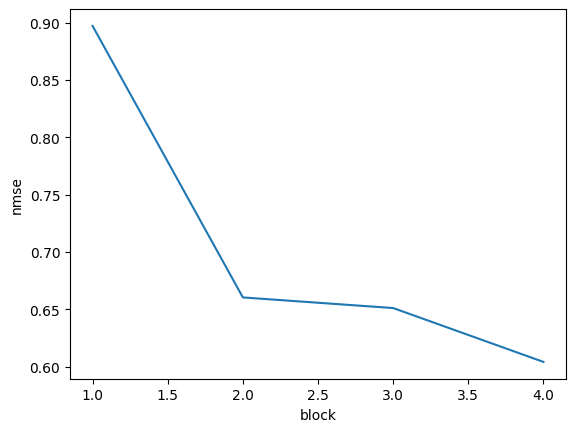

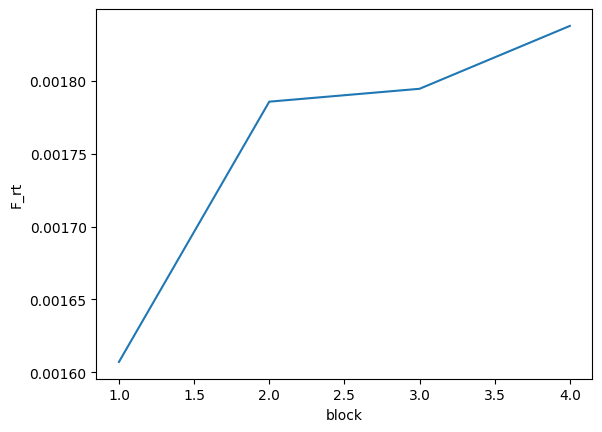

In [43]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='nmse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')

In [44]:
Xt = bttda.transform(X)
Xt_flat = tl.to_numpy(Xt)

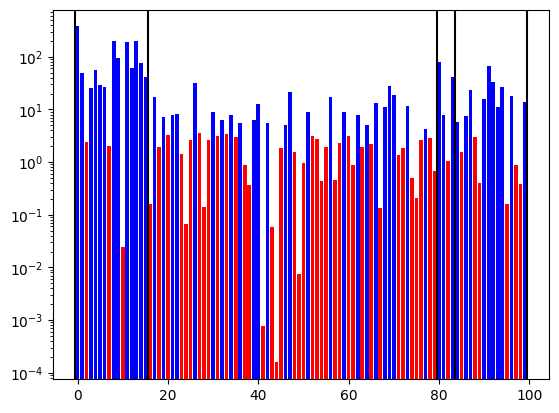

In [45]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < 0.05
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

<Axes: >

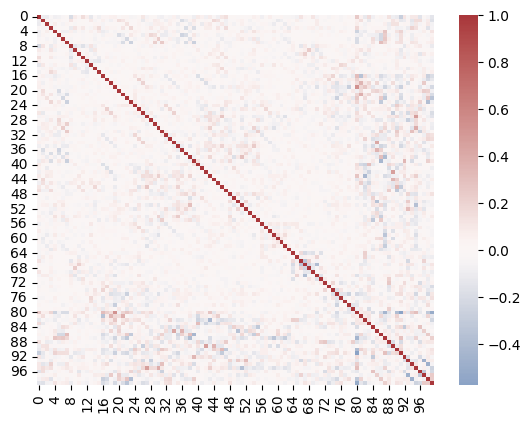

In [46]:
sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

      index       PC1       PC2      label
0         0  0.472892  3.506984  NonTarget
1         1 -2.113129  2.121363  NonTarget
2         2 -1.184591  0.970091  NonTarget
3         3  0.462040  0.416264     Target
4         4 -2.961330 -3.291227  NonTarget
...     ...       ...       ...        ...
1795   1795 -0.255506 -0.922933  NonTarget
1796   1796  0.838978 -0.163877  NonTarget
1797   1797  2.383492 -0.546548     Target
1798   1798 -0.864352  0.627373  NonTarget
1799   1799  0.445165  0.373367  NonTarget

[1800 rows x 4 columns]


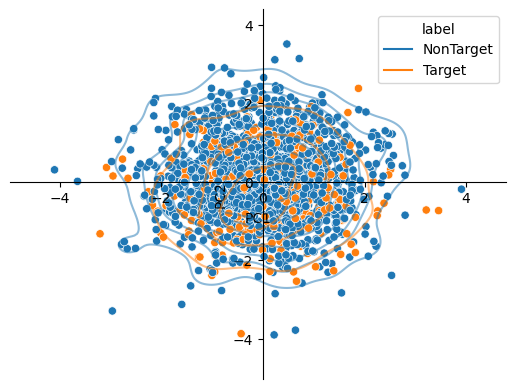

In [47]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',alpha=.5)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)